#### Imports

In [24]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

#### Starting Connection and Querying Data from Supabase

In [25]:
# Load environment variables from .env
load_dotenv()

# Fetch variables
USER = os.getenv("user")
PASSWORD = os.getenv("password")
HOST = os.getenv("host")
PORT = os.getenv("port")
DBNAME = os.getenv("dbname")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)
# If using Transaction Pooler or Session Pooler, we want to ensure we disable SQLAlchemy client side pooling -
# https://docs.sqlalchemy.org/en/20/core/pooling.html#switching-pool-implementations
# engine = create_engine(DATABASE_URL, poolclass=NullPool)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")

Connection successful!


In [26]:
query = """
SELECT *
FROM "RBPointProjection"
WHERE season BETWEEN 2018 AND 2024
"""

rb_df = pd.read_sql(query, engine)
print(rb_df.shape)
rb_df.head()

(10297, 67)


,player_id,player_name,team,season,week,opponent_team,fantasy_points_ppr,carries_prev,rushing_yards_prev,rushing_tds_prev,...,rb_targets_allowed_roll3_mean,rb_targets_allowed_roll5_mean,rb_receptions_allowed_roll3_mean,rb_receptions_allowed_roll5_mean,rb_rec_yards_allowed_roll3_mean,rb_rec_yards_allowed_roll5_mean,rb_rec_tds_allowed_roll3_mean,rb_rec_tds_allowed_roll5_mean,rb_fp_allowed_roll3_mean,rb_fp_allowed_roll5_mean
0,00-0023500,F.Gore,MIA,2018,1,TEN,6.1,261.0,961.0,3.0,...,6.000000,6.75,5.000000,5.50,35.500000,60.75,0.0,0.50,17.35,23.050
1,00-0023500,F.Gore,MIA,2018,2,NYJ,5.4,261.0,961.0,3.0,...,7.000000,8.50,5.500000,7.25,41.000000,63.25,0.0,0.25,18.80,27.375
2,00-0032104,A.Abdullah,MIN,2021,1,CIN,3.9,NaN,NaN,NaN,...,4.500000,4.75,4.000000,4.00,27.500000,35.50,0.5,0.50,26.80,23.150
3,00-0023500,F.Gore,MIA,2018,3,LV,1.2,261.0,961.0,3.0,...,4.500000,5.00,3.000000,3.75,30.500000,28.00,0.5,0.50,25.30,22.475
4,00-0023500,F.Gore,MIA,2018,4,NE,13.7,261.0,961.0,3.0,...,7.666667,8.00,5.666667,6.00,51.333333,58.00,0.0,0.00,24.60,26.225


#### Building Feature and Target Set

In [27]:
TARGET = "fantasy_points_ppr"

keys_df = rb_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", TARGET]

X = rb_df.drop(columns=[c for c in drop_cols if c in rb_df.columns]).copy()
y = rb_df[TARGET].copy()

X = X.drop(columns=["fantasy_points_ppr_prev"], errors="ignore")

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (10297, 59) y shape: (10297,)


#### Building Training, Validation, and Test Sets

In [28]:
train_mask = rb_df["season"].between(2018, 2022)
val_mask   = rb_df["season"].eq(2023)
test_mask  = rb_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)

print(X_train.shape, X_val.shape, X_test.shape)

(7273, 59) (1501, 59) (1523, 59)


### Linear Regression Model

In [29]:
X_train, X_val, X_test = X_train.fillna(0), X_val.fillna(0), X_test.fillna(0)
y_train, y_val, y_test = y_train.fillna(0), y_val.fillna(0), y_test.fillna(0)

In [30]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
lm_val_pred = linear_model.predict(X_val)
lm_test_pred = linear_model.predict(X_test)

In [32]:
mse = mean_squared_error(y_val, lm_val_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_val, lm_val_pred)

print(f"Linear Regression VAL RMSE: {rmse:.4f}")
print(f"Linear Regression VAL MAE : {mae:.4f}")

Linear Regression VAL RMSE: 6.3100
Linear Regression VAL MAE : 4.6815


In [33]:
mse = mean_squared_error(y_test, lm_test_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, lm_test_pred)

print(f"Linear Regression TEST RMSE: {rmse:.4f}")
print(f"Linear Regression TEST MAE : {mae:.4f}")

Linear Regression TEST RMSE: 6.3543
Linear Regression TEST MAE : 4.8288


### LightGBM

In [ ]:
model = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2",  
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=True)]
)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4830
[LightGBM] [Info] Number of data points in the train set: 7273, number of used features: 59
[LightGBM] [Info] Start training from score 8.649949
Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[95]	valid_0's l2: 40.2929


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


VAL RMSE: 6.3477
VAL MAE : 4.7980
Best iteration: 95


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

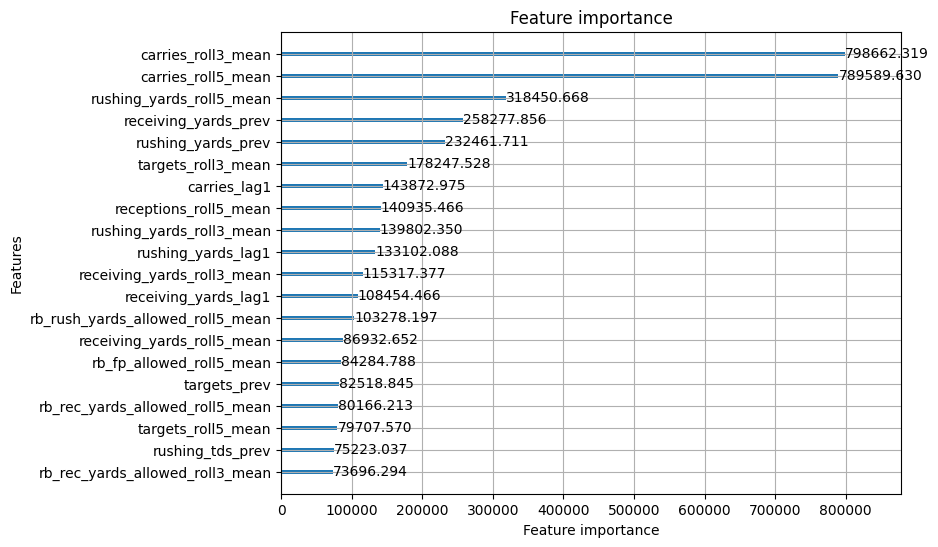

In [35]:
val_pred = model.predict(X_val, num_iteration=model.best_iteration_)
mse = mean_squared_error(y_val, val_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_val, val_pred)

print(f"VAL RMSE: {rmse:.4f}")
print(f"VAL MAE : {mae:.4f}")
print("Best iteration:", model.best_iteration_)
lgb.plot_importance(model, max_num_features=20, importance_type='gain', figsize=(8,6))

TEST RMSE: 6.2959
TEST MAE : 4.7931
Best iteration: 95


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

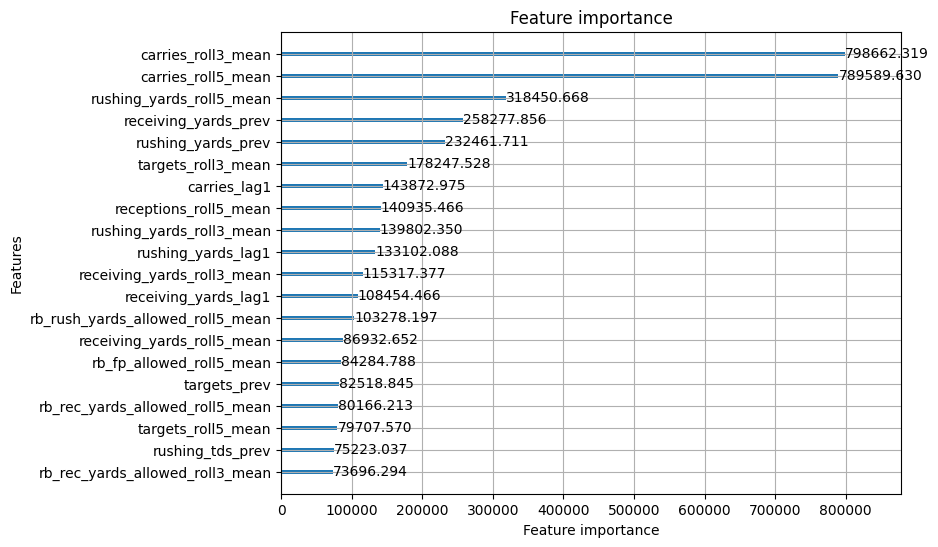

In [36]:
test_pred = model.predict(X_test, num_iteration=model.best_iteration_)
mse = mean_squared_error(y_test, test_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, test_pred)

print(f"TEST RMSE: {rmse:.4f}")
print(f"TEST MAE : {mae:.4f}")
print("Best iteration:", model.best_iteration_)
lgb.plot_importance(model, max_num_features=20, importance_type='gain', figsize=(8,6))

In [37]:
val_preds_df = keys_val.copy()
val_preds_df["pred_fantasy_points_ppr"] = val_pred
val_preds_df["actual_fantasy_points_ppr"] = y_val.reset_index(drop=True)

val_preds_df.sort_values(["season", "week", "pred_fantasy_points_ppr"], ascending=[True, True, False]).head(20)

,player_id,player_name,season,week,team,opponent_team,pred_fantasy_points_ppr,actual_fantasy_points_ppr
126,00-0033280,C.McCaffrey,2023,1,SF,PIT,21.822766,25.9
203,00-0033699,A.Ekeler,2023,1,LAC,MIA,19.443734,26.4
89,00-0032764,D.Henry,2023,1,TEN,NO,17.195662,13.9
609,00-0035700,J.Jacobs,2023,1,LV,DEN,15.343465,9.1
145,00-0033293,A.Jones,2023,1,GB,CHI,15.043841,26.7
230,00-0033893,D.Cook,2023,1,NYJ,BUF,14.774004,8.9
500,00-0035261,T.Pollard,2023,1,DAL,NYG,14.720838,22.2
391,00-0034791,N.Chubb,2023,1,CLE,CIN,14.536505,16.7
404,00-0034844,S.Barkley,2023,1,NYG,DAL,14.334033,9.3
465,00-0035243,M.Sanders,2023,1,CAR,ATL,14.305243,11.8


In [39]:
test_preds_df = keys_test.copy()
test_preds_df["pred_fantasy_points_ppr"] = test_pred
test_preds_df["actual_fantasy_points_ppr"] = y_test.reset_index(drop=True)

test_preds_df.sort_values(["season", "week", "pred_fantasy_points_ppr"], ascending=[True, True, False]).head(20)

,player_id,player_name,season,week,team,opponent_team,pred_fantasy_points_ppr,actual_fantasy_points_ppr
992,00-0037840,K.Williams,2024,1,LA,DET,15.744861,14.4
170,00-0033897,J.Mixon,2024,1,HOU,IND,15.106176,26.8
43,00-0032764,D.Henry,2024,1,BAL,KC,14.700114,10.6
814,00-0037248,J.Cook,2024,1,BUF,ARI,14.265919,13.3
833,00-0037256,R.White,2024,1,TB,WAS,14.157324,16.6
1031,00-0038120,B.Hall,2024,1,NYJ,SF,13.984264,18.3
135,00-0033699,A.Ekeler,2024,1,WAS,TB,13.792983,10.2
1077,00-0038542,B.Robinson,2024,1,ATL,PIT,13.642392,16.1
974,00-0037746,B.Robinson,2024,1,WAS,TB,13.522636,17.9
291,00-0034844,S.Barkley,2024,1,PHI,GB,13.138168,33.2


###### Similar to the QB models, our Linear Regression and LightGBM models have very similar performances with RB data. This is also likely due to the fact that the relationship between the features and target is quite simple. Our LightGBM model achieved a RMSE of ~6.3 across the validation and testing set. This is actually very surprising as ESPN's model achieved an RMSE of 6.78. This means our model is highly predictive and comparable to commercial models.